In [1]:
## Load all necessary libraries

import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cf
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas
from matplotlib.ticker import AutoMinorLocator
import os
import scipy
from netCDF4 import Dataset as netcdf_dataset
import matplotlib
matplotlib.matplotlib_fname()
print(plt.style.available)
matplotlib.rcParams['font.sans-serif'] = 'Arial'

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
## Load observations
obs_ds = xr.open_dataset('/Users/ak0920/Data/Precipitation/Obs_regridded_long2.nc')
P_obs = obs_ds["P"]
lats_obs = obs_ds.variables['latitude']
lons_obs = obs_ds.variables['longitude']

# Convert data to numpy array
P_obs_arr = np.array(P_obs)

# Take just DJF
monids = np.arange(0,1464,12)
monids2 = np.concatenate((monids,monids+1,monids+11))
P_DJF = P_obs_arr[:,np.sort(monids2),:,:]

# Take just MAM
monids2 = np.concatenate((monids+2,monids+3,monids+4))
P_MAM = P_obs_arr[:,np.sort(monids2),:,:]

# Take just JJA
monids2 = np.concatenate((monids+5,monids+6,monids+7))
P_JJA = P_obs_arr[:,np.sort(monids2),:,:]

# Take just SON
monids2 = np.concatenate((monids+8,monids+9,monids+10))
P_SON = P_obs_arr[:,np.sort(monids2),:,:]

# Hot to make a quick example plot for sanity checking
#plt.imshow(P_DJF[2,0,:,:])
#plt.show()

In [3]:
## Load observations
# Take just months
monids = np.arange(0,1464,12)
monids2 = monids+9
P_O = P_obs_arr[:,np.sort(monids2),:,:]

monids2 = monids+10
P_N = P_obs_arr[:,np.sort(monids2),:,:]

monids2 = monids+11
P_D = P_obs_arr[:,np.sort(monids2),:,:]

monids2 = monids
P_J = P_obs_arr[:,np.sort(monids2),:,:]

monids2 = monids+1
P_F = P_obs_arr[:,np.sort(monids2),:,:]

monids2 = monids+2
P_M = P_obs_arr[:,np.sort(monids2),:,:]

monids2 = monids+3
P_A = P_obs_arr[:,np.sort(monids2),:,:]


In [4]:
## To avoid mismatches in LSM relative to obs datasets, calculate LSM based on where obs are available
LSM1 = np.sum(np.isnan(P_obs_arr[:,1344,:,:,]),axis=0)
LSM2 = LSM1>0
LSM = np.abs(LSM2*1-1)

# Make ocean points NaN
mask_land = np.ones(LSM.shape)
for i in range(0,44):
    for j in range(0,41):        
        if LSM[i,j]==0:
            mask_land[i,j] = np.nan

# Check LSM looks sensible
#plt.imshow(mask_land*1)
#plt.show()

In [5]:
## Calculate the global lat-long area per 1° grid cell
# Assuming the earth is a perfect sphere
def gridsize(lat1):
   #https://en.wikipedia.org/wiki/Haversine_formula
   #https://stackoverflow.com/questions/639695/how-to-convert-latitude-or-longitude-to-meters/11172685#11172685
   lon1=200
   import math
   lat2=lat1
   lon2=lon1+1

   R = 6378.137 # // Radius of earth in km
   dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
   dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
   a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
   c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
   d = R * c
   return d * 1000 #; // meters


boxlo,boxla=np.array(np.meshgrid(np.arange(-179.5,180.5,1),np.arange(-89.5,90.5,1)))
sizes=np.ones(boxlo.shape)
grid=gridsize(boxla)

grid_nc=xr.DataArray(grid,coords={'lat':boxla[:,1],'lon':boxlo[1,:]},dims=['lat','lon'])
lat_size=110567 #in m
grid_nc['m2']=grid_nc*lat_size
grid_nc=grid_nc['m2']
grid_nc.to_netcdf('earth_m2.nc')

#plt.pcolormesh(boxlo[1,:],boxla[:,1],grid_nc)
#plt.colorbar()
#plt.show()

In [6]:
## Find ID of longitudes of global area grid for subset region where obs are available
lon_ids = np.arange(0,360,1)

which_id = boxlo[0,:] == np.array(lons_obs[0])
lon_id1 = lon_ids[which_id].item()
which_id = boxlo[0,:] == np.array(lons_obs[-1])
lon_id2 = lon_ids[which_id].item()+1
# boxlo[0,lon_id1:lon_id2] # Uncomment if want to check output
subsetlo = boxlo[0,lon_id1:lon_id2]

## Find ID of latitudes of global area grid for subset region
lat_ids = np.arange(0,180,1)

which_id = boxla[:,0] == np.array(lats_obs[0])
lat_id1 = lat_ids[which_id].item()
which_id = boxla[:,0] == np.array(lats_obs[-1])
lat_id2 = lat_ids[which_id].item()+1
#boxla[lat_id1:lat_id2,0] # Uncomment if want to check output
subsetla = boxla[lat_id1:lat_id2,0]

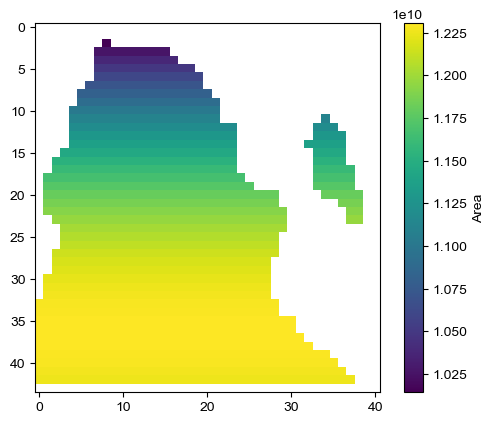

In [7]:
## Create area-weighted LSM
LSM_area = grid_nc[lat_id1:lat_id2,lon_id1:lon_id2]*mask_land

grid_lsm=xr.DataArray(LSM_area,coords={'lat':subsetla[:],'lon':subsetlo[:]},dims=['lat','lon'])
#lat_size=110567 #in m
#grid_lsm['m2']=grid_lsm
#grid_lsm=grid_lsm['m2']
grid_lsm=LSM_area['m2']
grid_lsm.to_netcdf('grid_lsm_m2.nc')

# Create plot to check
plt.imshow(LSM_area)
cbar = plt.colorbar(label="Area")
plt.show()


In [8]:
## Define all regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

## This correctly pulls out the ids for a defined region
# Select which region to use, or this could be a loop
regno = 0;

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

P_large_MAM = P_MAM[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_JJA = P_JJA[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_SON = P_SON[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_DJF = P_DJF[:,:,lat_id1:lat_id2,lon_id1:lon_id2]

P_large_O = P_O[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_N = P_N[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_D = P_D[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_J = P_J[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_F = P_F[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_M = P_M[:,:,lat_id1:lat_id2,lon_id1:lon_id2]
P_large_A = P_A[:,:,lat_id1:lat_id2,lon_id1:lon_id2]


In [13]:
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
areas3d = np.repeat(areas2d[:, :, np.newaxis], 366, axis=2)
areas4d = np.repeat(areas3d[:, :, :,np.newaxis], 8, axis=3)
# Convert to a fractional area
areas4d_frac = areas4d / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3da = np.repeat(areas2d[:, :, np.newaxis], 122, axis=2)
areas4da = np.repeat(areas3da[:, :, :,np.newaxis], 8, axis=3)
# Convert to a fractional area
areas4da_frac = areas4da / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)



In [10]:
## Re-order dimensions in precip. array
P_large_MAMa = np.transpose(P_large_MAM, (2,3,1,0))
P_large_JJAa = np.transpose(P_large_JJA, (2,3,1,0))
P_large_SONa = np.transpose(P_large_SON, (2,3,1,0))
P_large_DJFa = np.transpose(P_large_DJF, (2,3,1,0))

P_large_Oa = np.transpose(P_large_O, (2,3,1,0))
P_large_Na = np.transpose(P_large_N, (2,3,1,0))
P_large_Da = np.transpose(P_large_D, (2,3,1,0))
P_large_Ja = np.transpose(P_large_J, (2,3,1,0))
P_large_Fa = np.transpose(P_large_F, (2,3,1,0))
P_large_Ma = np.transpose(P_large_M, (2,3,1,0))
P_large_Aa = np.transpose(P_large_A, (2,3,1,0))



In [11]:
## Calculate area mean
P_large_MAM_ts = np.squeeze(np.nansum(np.nansum(P_large_MAMa * areas4d_frac,axis = 1),axis = 0))
P_large_JJA_ts = np.squeeze(np.nansum(np.nansum(P_large_JJAa * areas4d_frac,axis = 1),axis = 0))
P_large_SON_ts = np.squeeze(np.nansum(np.nansum(P_large_SONa * areas4d_frac,axis = 1),axis = 0))
P_large_DJF_ts = np.squeeze(np.nansum(np.nansum(P_large_DJFa * areas4d_frac,axis = 1),axis = 0))

# Ensure empty time steps are NaN, not 0 (area mean will have converted empty time steps to 0)
for i in range(0,366):
    for j in range(0,8):
        if np.isnan(P_large_DJFa[0,0,i,j]): # The lat-long ID might need updated from 0,0 for other regions
            P_large_DJF_ts[i,j] = np.nan
            P_large_MAM_ts[i,j] = np.nan # This SHOULD be the same for all months, but possibly worth having a loop for each
            P_large_JJA_ts[i,j] = np.nan
            P_large_SON_ts[i,j] = np.nan

# Calculate running mean
y_MAM_smooth2 = np.empty([103,8])
y_JJA_smooth2 = np.empty([103,8])
y_SON_smooth2 = np.empty([103,8])
y_DJF_smooth2 = np.empty([103,8])
for i in range(0,103):
    ts_id1 = i*3
    ts_id2 = i*3+60
    y_MAM_smooth2[i,:] = np.mean(P_large_MAM_ts[ts_id1:ts_id2,:], axis=0)
    y_JJA_smooth2[i,:] = np.mean(P_large_JJA_ts[ts_id1:ts_id2,:], axis=0)
    y_SON_smooth2[i,:] = np.mean(P_large_SON_ts[ts_id1:ts_id2,:], axis=0)
    y_DJF_smooth2[i,:] = np.mean(P_large_DJF_ts[ts_id1:ts_id2,:], axis=0)

In [40]:
## Calculate area mean
P_large_O_ts = np.squeeze(np.nansum(np.nansum(P_large_Oa * areas4da_frac,axis = 1),axis = 0))
P_large_N_ts = np.squeeze(np.nansum(np.nansum(P_large_Na * areas4da_frac,axis = 1),axis = 0))
P_large_D_ts = np.squeeze(np.nansum(np.nansum(P_large_Da * areas4da_frac,axis = 1),axis = 0))
P_large_J_ts = np.squeeze(np.nansum(np.nansum(P_large_Ja * areas4da_frac,axis = 1),axis = 0))
P_large_F_ts = np.squeeze(np.nansum(np.nansum(P_large_Fa * areas4da_frac,axis = 1),axis = 0))
P_large_M_ts = np.squeeze(np.nansum(np.nansum(P_large_Ma * areas4da_frac,axis = 1),axis = 0))
P_large_A_ts = np.squeeze(np.nansum(np.nansum(P_large_Aa * areas4da_frac,axis = 1),axis = 0))

# Ensure empty time steps are NaN, not 0 (area mean will have converted empty time steps to 0)
for i in range(0,122):
    for j in range(0,8):
        if np.isnan(P_large_Fa[0,0,i,j]): # The lat-long ID might need updated from 0,0 for other regions
            P_large_O_ts[i,j] = np.nan
            P_large_N_ts[i,j] = np.nan # This SHOULD be the same for all months, but possibly worth having a loop for each
            P_large_D_ts[i,j] = np.nan
            P_large_J_ts[i,j] = np.nan
            P_large_F_ts[i,j] = np.nan # This SHOULD be the same for all months, but possibly worth having a loop for each
            P_large_M_ts[i,j] = np.nan
            P_large_A_ts[i,j] = np.nan

# Calculate running mean
y_O_smooth2 = np.empty([103,8])
y_N_smooth2 = np.empty([103,8])
y_D_smooth2 = np.empty([103,8])
y_J_smooth2 = np.empty([103,8])
y_F_smooth2 = np.empty([103,8])
y_M_smooth2 = np.empty([103,8])
y_A_smooth2 = np.empty([103,8])
for i in range(0,103):
    ts_id1 = i
    ts_id2 = i+20
    y_O_smooth2[i,:] = np.mean(P_large_O_ts[ts_id1:ts_id2,:], axis=0)
    y_N_smooth2[i,:] = np.mean(P_large_N_ts[ts_id1:ts_id2,:], axis=0)
    y_D_smooth2[i,:] = np.mean(P_large_D_ts[ts_id1:ts_id2,:], axis=0)
    y_J_smooth2[i,:] = np.mean(P_large_J_ts[ts_id1:ts_id2,:], axis=0)
    y_F_smooth2[i,:] = np.mean(P_large_F_ts[ts_id1:ts_id2,:], axis=0)
    y_M_smooth2[i,:] = np.mean(P_large_M_ts[ts_id1:ts_id2,:], axis=0)
    y_A_smooth2[i,:] = np.mean(P_large_A_ts[ts_id1:ts_id2,:], axis=0)

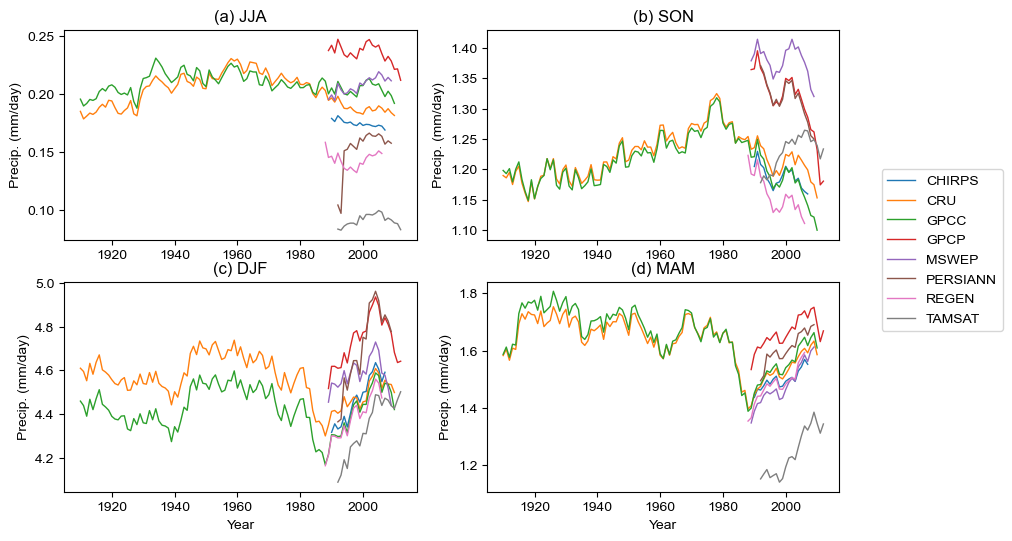

In [17]:
# Create Figure 6

labels=['CHIRPS','CRU','GPCC','GPCP','MSWEP','PERSIANN','REGEN','TAMSAT']

#fig, ax = plt.subplots()
fig, axs = plt.subplots(2,2, figsize=(10,6))

for i in range(0,8):
    axs[0,0].plot(np.arange(1910., 2013.), y_JJA_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[0,0].set_title('(a) JJA',fontname = 'arial')
    axs[0,1].plot(np.arange(1910., 2013.), y_SON_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[0,1].set_title('(b) SON',fontname = 'arial')
    axs[1,0].plot(np.arange(1910., 2013.), y_DJF_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[1,0].set_title('(c) DJF',fontname = 'arial')
    axs[1,1].plot(np.arange(1910., 2013.), y_MAM_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[1,1].set_title('(d) MAM',fontname = 'arial')
    axs[0,0].set_ylabel('Precip. (mm/day)')
    # axs[0,0].set_xlabel('Year');
    axs[0,1].set_ylabel('Precip. (mm/day)')
    # axs[0,1].set_xlabel('Year');
    axs[1,0].set_ylabel('Precip. (mm/day)')
    axs[1,0].set_xlabel('Year');
    axs[1,1].set_ylabel('Precip. (mm/day)')
    axs[1,1].set_xlabel('Year');

# fig.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1.1, 1.15),ncol=1)

# plt.legend(loc='center left', bbox_to_anchor=(1.1, 1.15),ncol=1)
# plt.legend(loc='center left', bbox_to_anchor=(0.1, 0.335),ncol=1)
plt.savefig('Fig6Observation_timeseries.pdf', bbox_inches='tight')
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


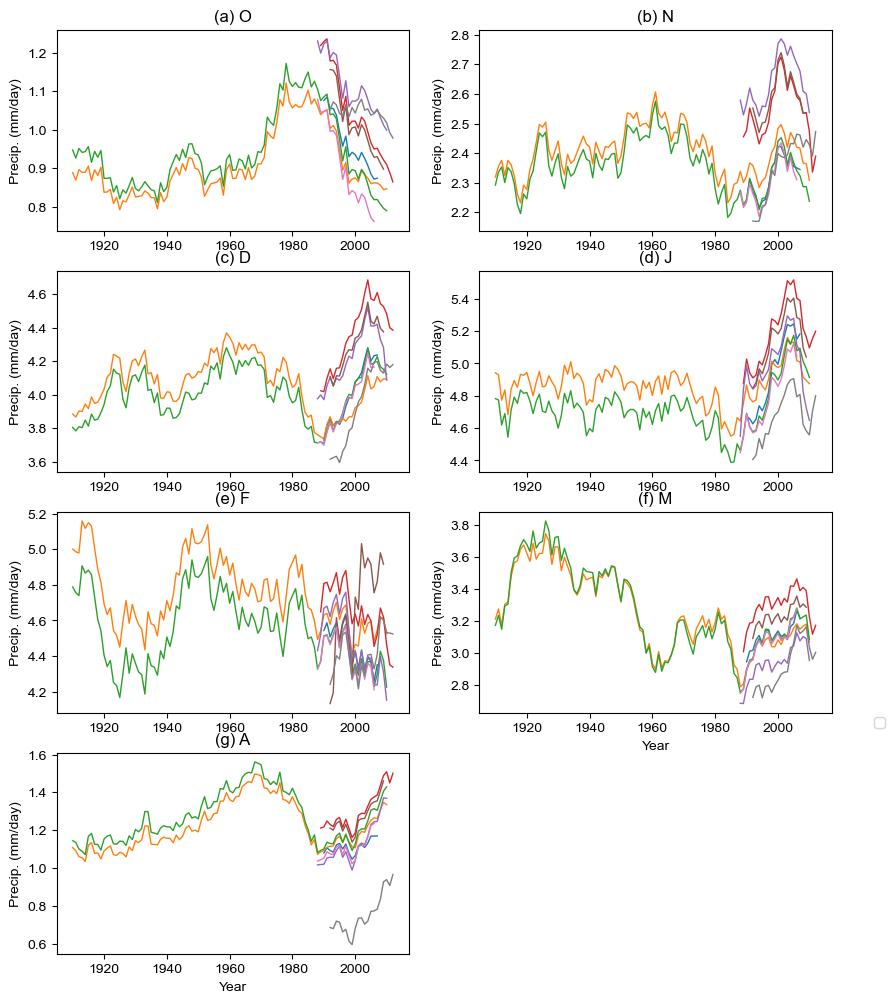

In [41]:
# Create supplementary monthly figure

labels=['CHIRPS','CRU','GPCC','GPCP','MSWEP','PERSIANN','REGEN','TAMSAT']

#fig, ax = plt.subplots()
fig, axs = plt.subplots(4,2, figsize=(10,12))

for i in range(0,8):
    axs[0,0].plot(np.arange(1910., 2013.), y_O_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[0,0].set_title('(a) O',fontname = 'arial')
    axs[0,0].set_ylabel('Precip. (mm/day)')
    
    axs[0,1].plot(np.arange(1910., 2013.), y_N_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[0,1].set_title('(b) N',fontname = 'arial')
    axs[0,1].set_ylabel('Precip. (mm/day)')
    
    axs[1,0].plot(np.arange(1910., 2013.), y_D_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[1,0].set_title('(c) D',fontname = 'arial')
    axs[1,0].set_ylabel('Precip. (mm/day)')
    
    axs[1,1].plot(np.arange(1910., 2013.), y_J_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[1,1].set_title('(d) J',fontname = 'arial')
    axs[1,1].set_ylabel('Precip. (mm/day)')

    axs[2,0].plot(np.arange(1910., 2013.), y_F_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[2,0].set_title('(e) F',fontname = 'arial')
    axs[2,0].set_ylabel('Precip. (mm/day)')
    
    axs[2,1].plot(np.arange(1910., 2013.), y_M_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[2,1].set_title('(f) M',fontname = 'arial')
    axs[2,1].set_ylabel('Precip. (mm/day)')
    axs[2,1].set_xlabel('Year');
    
    axs[3,0].plot(np.arange(1910., 2013.), y_A_smooth2[:,i], linewidth=1,  label=labels[i])
    axs[3,0].set_title('(g) A',fontname = 'arial')
    axs[3,0].set_ylabel('Precip. (mm/day)')
    axs[3,0].set_xlabel('Year');
    
axs[3, 1].axis('off')

# fig.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1.1, 1.15),ncol=1)

# plt.legend(loc='center left', bbox_to_anchor=(1.1, 1.15),ncol=1)
# plt.legend(loc='center left', bbox_to_anchor=(0.1, 0.335),ncol=1)
plt.savefig('SuppFigZ_Observation_timeseries_months.pdf', bbox_inches='tight')
plt.show()

